# Student Performance Indicator

### Life cycle of a machine learning project
- Understanding the problem statement
- Data collection
- Data checks to perform
- Exploratory Data Analysis (EDA)
- Data pre-processing
- Model training
- Choose best model

## 1. Problem Statement
This project seeks to understand how student's performance, measured by test scores, is affected by other variables such as Gender, Ethnicity, Parental Level of Education, whether the student receives lunch at school, and whether the student participated in a test preparation course.

## 2. Data Collection
Dataset Source: [Kaggle - Student Performance Dataset](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?resource=download&select=StudentsPerformance.csv)

The dataset consists of 8 columns and 1000 rows

### 2.1 Import Data and Required Packages
Importing Pandas, NumPy, Matplotlib, Seaborn, and Warnings Library.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import janitor


%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as a Pandas Dataframe

In [7]:
df = pd.read_csv('data/StudentsPerformance.csv')
df = df.clean_names()

#### Show the top 5 records

In [8]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Shape of the dataset

In [9]:
df.shape

(1000, 8)

### 2.2 Dataset Information
- Gender: Sex of students -> (Male/Female)
- Race/Ethnicity: Ethnicity of Students -> (Group A, B, C, D, E)
- Parental Level of Education: Parent's final education -> (High School, Some College, Associate's Degree, Bachelor's Degree,  Master's Degree)
- Lunch: Student's lunch program participation -> (standard or free/reduced)
- Test preparation Course: -> (Completed, Not Completed)
- Math Score
- Reading Score
- Writing Score 

## Data Checks to Perform
- Check missing values
- Check duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of dataset
- Check various categories present in the different categorical columns

### 3.1 Check Missing Values

In [10]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

There are no missing values in the dataset.

### 3.2 Check Duplicates

In [11]:
if df.duplicated().sum() > 0:
    print('There are duplicate values in the dataset')
#    df.drop_duplicates(inplace=True)
else:
    print('There are no duplicate values in the dataset')

There are no duplicate values in the dataset


There are no duplicates in the dataset.

### 3.3 Check data types

In [12]:
# Check null count and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


### 3.4 Checking the number of unique values of each column

In [13]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

### 3.5 Check statistics of data set

In [14]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight
- From the above description of numerical data, the means are very close to each other -- between 66 and 68.05
- All standard deviations are also close -- between 14.6 and 15.19
- The minimum score for math is 0; the minimum scores for writing (10) and reading (17) are much higher

### 3.6 Exploring the Data

In [16]:
# Gender
print("Categories in 'gender' column: ", end=" ")
print(df['gender'].unique())

# Race/Ethnicity
print("Categories in 'race/ethnicity' column: ", end=" ")
print(df['race_ethnicity'].unique())

# Parental Level of Education
print("Categories in 'parental level of education' column: ", end=" ")
print(df['parental_level_of_education'].unique())

# Lunch
print("Categories in 'lunch' column: ", end=" ")
print(df['lunch'].unique())

# Test Preparation Course
print("Categories in 'test preparation course' column: ", end=" ")
print(df['test_preparation_course'].unique())

Categories in 'gender' column:  <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race/ethnicity' column:  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'parental level of education' column:  <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' column:  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' column:  <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [27]:
# Define numerical and categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype in ['int64', 'float64']]
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']

# Print Columns
print("We have {} numerical features : {}".format(len(numeric_features), numeric_features))
print("\nWe have {} categorical features : {}".format(len(categorical_features), categorical_features))

We have 5 numerical features : ['math_score', 'reading_score', 'writing_score', 'total_score', 'average_score']

We have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


### 3.7 Adding Columns for "Total Score" and "Average Score"

I can now create a model to predict total score, average score, as well as the individual scores if desired. 

In [31]:
# Total Score
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']

# Average Score
df['average_score'] = df['total_score'] / 3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [32]:
# Correlation between total_score and average_score
df[['total_score', 'average_score']].corr()

# correlation between the numerical features
df[['math_score', 'reading_score', 'writing_score']].corr()

,math_score,reading_score,writing_score
math_score,1.000000,0.817580,0.802642
reading_score,0.817580,1.000000,0.954598
writing_score,0.802642,0.954598,1.000000


In [22]:
reading_full = df[df['reading_score'] == 100]['average_score'].count()
print("Number of students with a perfect reading score: ", reading_full)

writing_full = df[df['writing_score'] == 100]['average_score'].count()
print("Number of students with a perfect writing score: ", writing_full)

math_full = df[df['math_score'] == 100]['average_score'].count()
print("Number of students with a perfect math score: ", math_full)

Number of students with a perfect reading score:  17
Number of students with a perfect writing score:  14
Number of students with a perfect math score:  7


In [40]:
# Reading score below the 25th percentile of all reading scores
reading_below_25pct = len(df[df['reading_score'] < df['reading_score'].quantile(0.25)])
print(f"The 25th percentile of reading scores is {df['reading_score'].quantile(0.25)}. {reading_below_25pct} students read below the 25th percentile.\n")

# Writing score below the 25th percentile of all writing scores
writing_below_25pct = len(df[df['writing_score'] < df['writing_score'].quantile(0.25)])
print(f"The 25th percentile of writing scores is {df['writing_score'].quantile(0.25)}. {writing_below_25pct} students write below the 25th percentile.\n")

# Math score below the 25th percentile of all math scores
math_below_25pct = len(df[df['math_score'] < df['math_score'].quantile(0.25)])
print(f"The 25th percentile of math scores is {df['math_score'].quantile(0.25)}. {math_below_25pct} students score below the 25th percentile.")

The 25th percentile of reading scores is 59.0. 237 students read below the 25th percentile.

The 25th percentile of writing scores is 57.75. 250 students write below the 25th percentile.

The 25th percentile of math scores is 57.0. 248 students score below the 25th percentile.


#### Insights

- From the above, we that students performed worst in math
- Best performance is in reading
- Reading and writing scores are most highly correlated (r ~ 0.95)

## Data Visualization

### 4.1 Visualize average score distribution to make some conclusion
- Histogram
- Kernel Distribution Function (KDE)

#### 4.1.1 Histogram and KDE

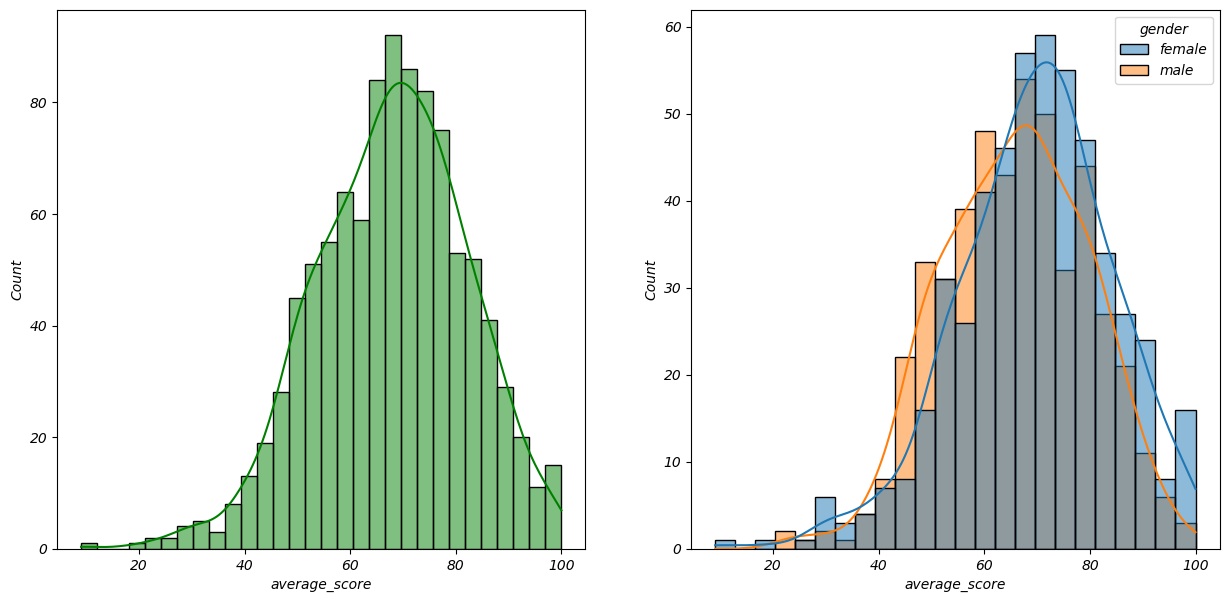

In [41]:
# Average score by gender
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df, x='average_score', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x='average_score', kde=True, hue='gender')
plt.show()

# Total score by gender

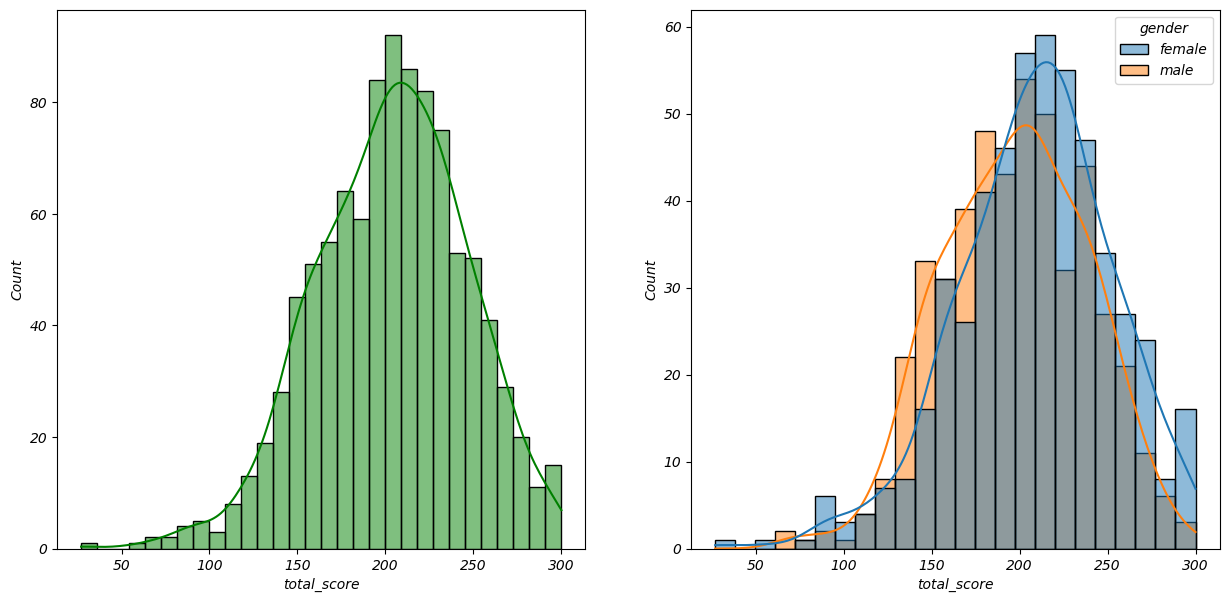

In [42]:
# Total score by gender
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df, x='total_score', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x='total_score', kde=True, hue='gender')
plt.show()

# Total score by gender

#### Insights
- Female students tend to perform better than male students

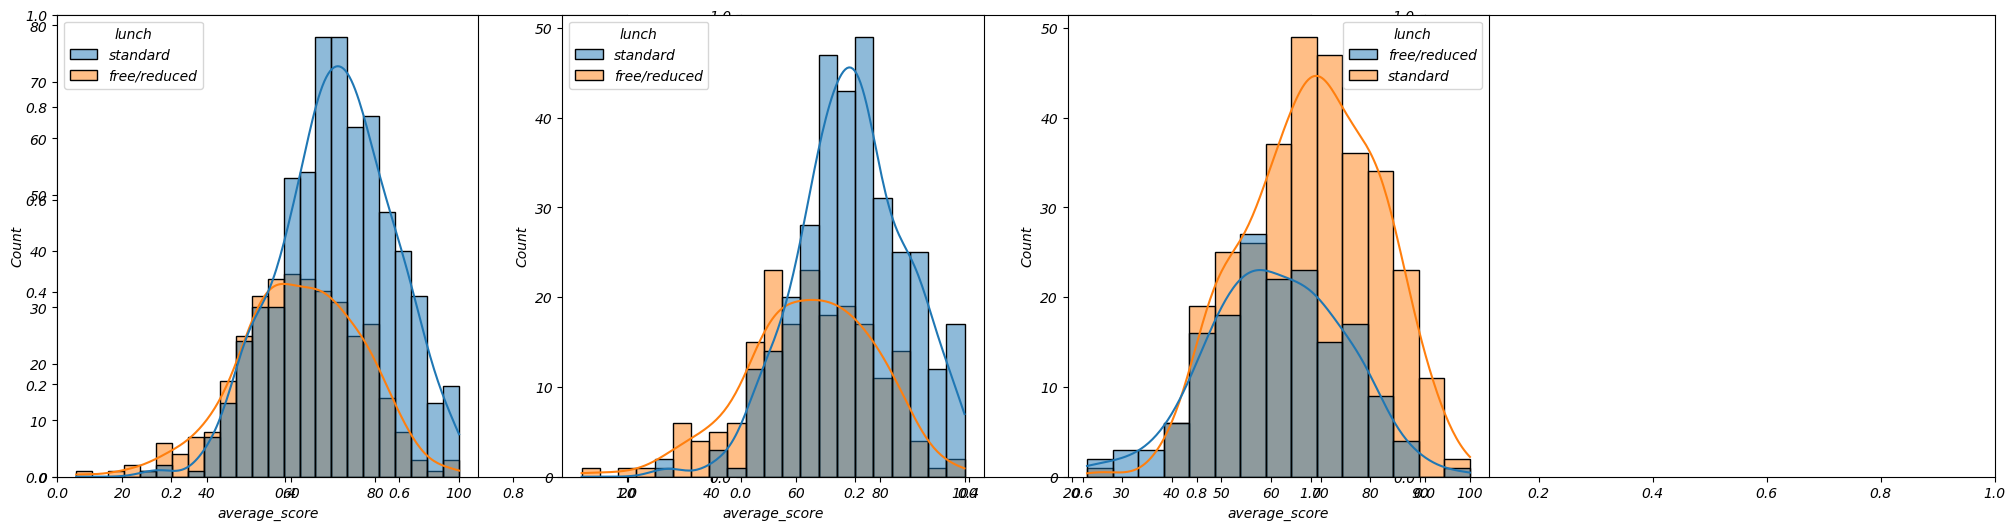

In [25]:
# Average score by lunch program participation
plt.subplots(1, 3, figsize=(25, 6))
plt.subplot(141)
sns.histplot(data=df, x='average_score', kde=True, hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'], x='average_score', kde=True, hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'], x='average_score', kde=True, hue='lunch')
plt.show()

#### Insights

- Standard lunch helps in performing well in exams
- This result holds regardless of gender